In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df=pd.read_csv("data.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 1.6 MB


In [4]:
df=df.drop(["area_type","availability","society","balcony"],axis=1)
df.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [5]:
df.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [6]:
df["location"].value_counts()
df["location"]=df["location"].fillna("sarjapur Road")
df["location"].value_counts()

location
Whitefield                                         540
Sarjapur  Road                                     399
Electronic City                                    302
Kanakpura Road                                     273
Thanisandra                                        234
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1306, dtype: int64

In [7]:
df['size'].value_counts()
df['size'] = df['size'].fillna('2 BHK')
df['size'].value_counts()

size
2 BHK         5215
3 BHK         4310
4 Bedroom      826
4 BHK          591
3 Bedroom      547
1 BHK          538
2 Bedroom      329
5 Bedroom      297
6 Bedroom      191
1 Bedroom      105
8 Bedroom       84
7 Bedroom       83
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
27 BHK           1
19 BHK           1
16 BHK           1
43 Bedroom       1
14 BHK           1
12 Bedroom       1
13 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [8]:
df.isnull().sum()

location       0
size           0
total_sqft     0
bath          73
price          0
dtype: int64

In [9]:
med_bath = df["bath"].median() 
med_bath
df["bath"] = df["bath"].fillna(med_bath)

In [10]:
df["bath"]=df["bath"].astype(int)
df["bath"].unique()

array([ 2,  5,  3,  4,  6,  1,  9,  8,  7, 11, 10, 14, 27, 12, 16, 40, 15,
       13, 18])

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df["location"].value_counts()
loc = df["location"].value_counts()
loc_less_than_10 = loc[loc < 10]

df["location"] = df["location"].apply(lambda x: "others" if x in loc_less_than_10 else x)
df["location"].value_counts()

location
others                   2782
Whitefield                507
Sarjapur  Road            364
Electronic City           273
Thanisandra               224
                         ... 
Poorna Pragna Layout       10
Marsur                     10
1st Block Koramangala      10
Gunjur Palya               10
Dodsworth Layout           10
Name: count, Length: 248, dtype: int64

In [13]:
out=[int(i.split()[0]) for i in df["size"]]
df["bhk"]=out
df

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5,120.00,4
2,Uttarahalli,3 BHK,1440,2,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3,95.00,3
4,Kothanur,2 BHK,1200,2,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715,3,112.00,3
13315,Whitefield,5 Bedroom,3453,4,231.00,5
13316,others,4 BHK,3600,5,400.00,4
13317,Raja Rajeshwari Nagar,2 BHK,1141,2,60.00,2


In [14]:
def clean_sqft(sqft):
    l = sqft.split("-")
    if len(l) == 2:
        return (float(l[0]) + float(l[1])) / 2
    try:
        return float(l[0])
    except:
        return None
df["total_sqft"] = df["total_sqft"].apply(clean_sqft)
df["total_sqft"] = df["total_sqft"].fillna(round(df["total_sqft"].mean()))

In [15]:
df["price_per_sqft"] = df["price"] * 100000 / df["total_sqft"]
df

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
13315,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926
13316,others,4 BHK,3600.0,5,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2,60.00,2,5258.545136


In [16]:
df=df[df["total_sqft"]/df["bhk"]>=300]
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,11705.000000,11705.000000,11705.000000,11705.000000,11705.000000
mean,1614.029039,2.579667,114.455648,2.666809,6405.091922
std,1296.481391,1.099383,156.421987,0.995743,4281.960473
min,300.000000,1.000000,8.440000,1.000000,267.829813
25%,1120.000000,2.000000,50.000000,2.000000,4253.521127
50%,1314.000000,2.000000,71.000000,3.000000,5348.837209
75%,1720.000000,3.000000,120.000000,3.000000,7000.000000
max,52272.000000,16.000000,3600.000000,16.000000,176470.588235


In [17]:
df=df[df["bhk"]<=6]

In [18]:
df=df[df["bath"]<df["bhk"]+2]
df

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
13315,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926
13316,others,4 BHK,3600.0,5,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2,60.00,2,5258.545136


<Axes: xlabel='price_per_sqft'>

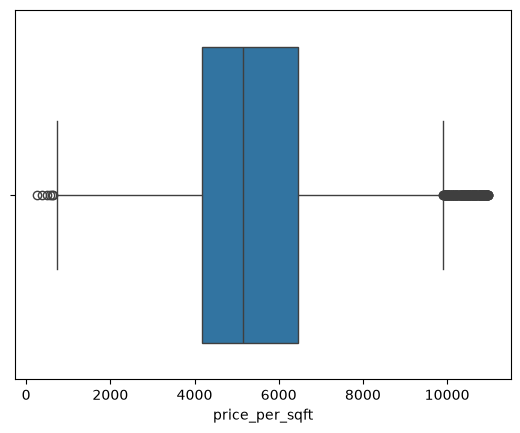

In [19]:
q1 = df["price_per_sqft"].quantile(0.25)
q3 = df["price_per_sqft"].quantile(0.75)
IQR = q3 - q1
lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR    
df = df[(df["price_per_sqft"] >= lower) & (df["price_per_sqft"] <= upper)]
sns.boxplot(x="price_per_sqft", data=df)


In [20]:
df.reset_index(inplace=True)
df = df.drop(["index","size","price_per_sqft"],axis=1)
df

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056.0,2,39.07,2
1,Chikka Tirupathi,2600.0,5,120.00,4
2,Uttarahalli,1440.0,2,62.00,3
3,Lingadheeranahalli,1521.0,3,95.00,3
4,Kothanur,1200.0,2,51.00,2
...,...,...,...,...,...
10542,Bellandur,1262.0,2,47.00,2
10543,Green Glen Layout,1715.0,3,112.00,3
10544,Whitefield,3453.0,4,231.00,5
10545,Raja Rajeshwari Nagar,1141.0,2,60.00,2


In [21]:
from sklearn.preprocessing import LabelEncoder,StandardScaler,Normalizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import r2_score,mean_absolute_error

In [22]:
encoder = LabelEncoder()
df["encoded_loc"] = encoder.fit_transform(df["location"])
df.head()

,location,total_sqft,bath,price,bhk,encoded_loc
0,Electronic City Phase II,1056.0,2,39.07,2,80
1,Chikka Tirupathi,2600.0,5,120.00,4,61
2,Uttarahalli,1440.0,2,62.00,3,230
3,Lingadheeranahalli,1521.0,3,95.00,3,163
4,Kothanur,1200.0,2,51.00,2,155


In [23]:
x = df.drop(["location", "price"], axis=1)
y = df.price

In [24]:
Xtrain, Xtest, ytrain, ytest = train_test_split(x, y, test_size=0.3, random_state=42)

In [25]:
model = RandomForestRegressor(random_state=42)
params = {
    "n_estimators": [100, 150, 200, 250, 300],
    "max_depth": [3, 4, 5, 6, 7]
}
grid = GridSearchCV(estimator=model, param_grid=params, cv=5)

grid.fit(Xtrain, ytrain)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Best params: {'max_depth': 4, 'n_estimators': 100}
Best score: 0.6347186998650205


In [26]:
#model.fit(Xtrain, ytrain)

In [27]:
ypred = grid.predict(Xtest)
ypred

array([34.17416667, 69.69249278, 79.97275632, ..., 55.16735564,
       49.81504424, 49.81504424], shape=(3165,))

In [28]:
print("training eff:", grid.score(Xtrain, ytrain))
print("testing eff:", grid.score(Xtest, ytest))

training eff: 0.7931178780546614
testing eff: 0.623638272983849


In [29]:
print("R2 score:", r2_score(ytest, ypred))
print("Mean Absolute Error:", mean_absolute_error(ytest, ypred))

R2 score: 0.623638272983849
Mean Absolute Error: 20.513181790437155


In [30]:
df.to_csv("cleaned_data.csv")


In [31]:
import joblib
joblib.dump(grid,"rf_model.joblib")

['rf_model.joblib']